In [112]:
from typing import TypedDict, List, Dict, Any
from selenium.webdriver.chrome.webdriver import WebDriver

# 상태 정의
class AgentState(TypedDict):
    """LangGraph의 상태를 정의합니다."""
    driver: WebDriver | None
    current_url: str
    human_input: str
    result: str
    next_step: str
    elements_info: List[Dict[str, Any]]  # 분석된 요소 정보 저장
    waiting_for_element_selection: bool  # 요소 선택 대기 중인지 여부

In [113]:
from langchain_core.tools import tool
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.action_chains import ActionChains
import time

# Selenium 도구 정의
@tool
def fill_text(driver: WebDriver, selector: str, text: str) -> str:
    """주어진 CSS 셀렉터에 해당하는 웹 요소에 텍스트를 입력합니다.
    - driver: Selenium WebDriver 객체.
    - selector: CSS 셀렉터. 예: '#query', '.search_box'
    - text: 입력할 텍스트. 예: '환율'
    """
    try:
        element = WebDriverWait(driver, 10).until(
            EC.element_to_be_clickable((By.CSS_SELECTOR, selector))
        )
        element.clear()  # 기존 텍스트 지우기
        element.send_keys(text)
        return f"텍스트 '{text}'가 '{selector}'에 성공적으로 입력되었습니다."
    except Exception as e:
        return f"텍스트 입력 실패: {e}"

@tool
def click_element(driver: WebDriver, selector: str) -> str:
    """주어진 CSS 셀렉터에 해당하는 웹 요소를 클릭합니다.
    - driver: Selenium WebDriver 객체.
    - selector: CSS 셀렉터. 예: '#search_button', '.btn_search'
    """
    try:
        element = WebDriverWait(driver, 10).until(
            EC.element_to_be_clickable((By.CSS_SELECTOR, selector))
        )
        element.click()
        return f"'{selector}' 요소가 성공적으로 클릭되었습니다."
    except Exception as e:
        return f"요소 클릭 실패: {e}"

@tool
def click_element_by_index(driver: WebDriver, index: int, elements_info: List[Dict[str, Any]]) -> str:
    """분석된 요소 목록에서 인덱스로 요소를 클릭합니다.
    - driver: Selenium WebDriver 객체.
    - index: 클릭할 요소의 인덱스 (1부터 시작)
    - elements_info: 분석된 요소 정보 리스트
    """
    try:
        if index < 1 or index > len(elements_info):
            return f"잘못된 인덱스입니다. 1-{len(elements_info)} 범위의 번호를 입력해주세요."
        
        element_info = elements_info[index - 1]
        
        # 다양한 방법으로 요소를 찾기
        element = None
        
        # 1. ID로 찾기
        if element_info['id'] != "N/A":
            try:
                element = driver.find_element(By.ID, element_info['id'])
            except:
                pass
        
        # 2. ID로 찾지 못했으면 XPath로 재검색
        if not element:
            try:
                elements = driver.find_elements(
                    By.XPATH, 
                    "//button | //a | //input[@type='submit'] | //input[@type='button'] | //div[@role='button'] | //span[@role='button'] | //*[contains(@class, 'btn')] | //*[contains(@class, 'button')]"
                )
                visible_elements = [el for el in elements if el.is_displayed()]
                if index - 1 < len(visible_elements):
                    element = visible_elements[index - 1]
            except Exception as e:
                return f"요소를 찾을 수 없습니다: {e}"
        
        if not element:
            return f"[{index}] 해당 요소를 찾을 수 없습니다."
        
        # 클릭 시도 - 여러 방법 사용
        click_methods = [
            ("일반 클릭", lambda: element.click()),
            ("JavaScript 클릭", lambda: driver.execute_script("arguments[0].click();", element)),
            ("ActionChains 클릭", lambda: ActionChains(driver).move_to_element(element).click().perform()),
            ("스크롤 후 클릭", lambda: scroll_and_click(driver, element))
        ]
        
        for method_name, click_func in click_methods:
            try:
                print(f"{method_name} 시도 중...")
                
                # 요소가 클릭 가능할 때까지 대기
                WebDriverWait(driver, 5).until(
                    EC.element_to_be_clickable(element)
                )
                
                click_func()
                return f"[{index}] {element_info['tag']} 요소가 {method_name}으로 성공적으로 클릭되었습니다."
                
            except Exception as e:
                print(f"{method_name} 실패: {e}")
                continue
        
        # 모든 방법이 실패한 경우 요소 정보 출력
        try:
            location = element.location
            size = element.size
            is_displayed = element.is_displayed()
            is_enabled = element.is_enabled()
            
            return f"[{index}] 클릭 실패. 요소 상태: 위치({location}), 크기({size}), 표시됨({is_displayed}), 활성화됨({is_enabled})"
        except:
            return f"[{index}] 모든 클릭 방법이 실패했습니다. 다른 요소를 선택해보세요."
            
    except Exception as e:
        return f"요소 클릭 중 예상치 못한 오류: {e}"

def scroll_and_click(driver, element):
    """요소를 화면 중앙으로 스크롤한 후 클릭합니다."""
    driver.execute_script("arguments[0].scrollIntoView({behavior: 'smooth', block: 'center'});", element)
    time.sleep(0.5)  # 스크롤 완료 대기
    element.click()

@tool
def press_key(driver: WebDriver, selector: str, key: str) -> str:
    """주어진 CSS 셀렉터에 해당하는 웹 요소에 특정 키를 누릅니다.
    - driver: Selenium WebDriver 객체.
    - selector: CSS 셀렉터. 예: '#query'
    - key: 누를 키. 현재 'ENTER'만 지원합니다.
    """
    try:
        if key.upper() != "ENTER":
            return f"오류: 지원하지 않는 키 '{key}'입니다. 'ENTER'만 사용할 수 있습니다."
        
        element = WebDriverWait(driver, 10).until(
            EC.element_to_be_clickable((By.CSS_SELECTOR, selector))
        )
        element.send_keys(Keys.ENTER)
        return f"'{selector}' 요소에 '{key}' 키를 성공적으로 눌렀습니다."
    except Exception as e:
        return f"키 입력 실패: {e}"

In [114]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI
import json
from dotenv import load_dotenv
load_dotenv()

# 노드 함수 정의
def create_driver():
    """크롬 WebDriver를 생성하여 반환합니다."""
    options = Options()
    # options.add_argument("--headless") # headless 모드로 실행하려면 주석 해제
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    driver = webdriver.Chrome(options=options)
    driver.set_window_size(1280, 720)
    return driver

def navigate_to_page(state: AgentState):
    """지정된 URL로 이동하고 드라이버를 상태에 저장합니다."""
    print("\n--- 페이지 탐색 노드 실행 ---")
    driver = create_driver()
    url = state.get("current_url", "https://www.naver.com")
    
    print(f"브라우저를 열고 {url}로 이동합니다.")
    driver.get(url)
    return {
        "driver": driver, 
        "current_url": url, 
        "result": f"{url}로 이동했습니다.",
        "elements_info": [],
        "waiting_for_element_selection": False
    }
    
def human_input_waiter(state: AgentState):
    """사용자에게 입력을 요청하고 상태를 업데이트합니다."""
    print("\n--- 사용자 입력 대기 노드 실행 ---")
    
    elements_info = state.get("elements_info", [])
    waiting_for_selection = state.get("waiting_for_element_selection", False)

    if waiting_for_selection and elements_info:
        print("\n" + "="*60)
        print("🔍 관련성 높은 클릭 가능한 요소들 (중요도 순)")
        print("="*60)
        for el in elements_info:
            # 점수 표시 (디버깅 목적, 실제 배포시에는 제거 가능)
            score_info = f" (관련도: {el.get('score', 0)}점)" if 'score' in el else ""
            print(f"[{el['index']}] {el['tag']}태그 - 텍스트: '{el['text']}'{score_info}")
            if el['id'] != "N/A":
                print(f"    └─ ID: {el['id']}")
            if len(el['class']) < 40:  # 클래스가 짧을 때만 표시
                print(f"    └─ 클래스: {el['class']}")
        print("="*60)
        print("💡 사용법:")
        print("   - 번호 입력: 해당 요소를 클릭합니다 (예: '3')")
        print("   - 다른 명령: 새로운 작업을 수행합니다 (예: '검색창에 텍스트 입력')")
        print("   - 종료: '그만'을 입력하면 종료합니다")
    else:
        print("다음 작업을 입력해주세요.")
        print("예: '검색창에 환율 입력해줘', '검색 버튼을 클릭해줘', '그만'")

    user_input = input("입력: ").strip()
    
    # 숫자만 입력된 경우 (요소 선택)
    if user_input.isdigit() and waiting_for_selection:
        return {
            "human_input": f"요소 {user_input}번을 클릭해줘", 
            "waiting_for_element_selection": False
        }
    
    return {"human_input": user_input}

def error_node(state: AgentState):
    """오류 발생 시 브라우저를 종료하고 작업을 중단합니다."""
    print("\n--- 오류 노드 실행 ---")
    driver = state.get("driver")
    if driver:
        driver.quit()
    print("오류 발생. 브라우저가 종료되고 작업이 중단되었습니다.")
    return {"result": "오류로 인해 작업 중단"}

def done_node(state: AgentState):
    """작업 완료 시 브라우저를 종료하고 종료합니다."""
    print("\n--- 작업 완료 노드 실행 ---")
    driver = state.get("driver")
    if driver:
        driver.quit()
    print("작업 완료. 브라우저가 종료되었습니다.")
    return {"result": "모든 작업 완료"}

def should_continue(state: AgentState):
    """사용자 입력에 따라 계속할지 종료할지 결정합니다."""
    if state.get("human_input", "").strip() == "그만":
        return "end"
    else:
        return "continue"

In [115]:
# * 페이지 분석하여 사용자의 개입에서 참고 자료로 사용
def page_analyzer_node(state: AgentState):
    """현재 페이지의 상호작용 가능한 요소들을 분석하고 상태를 업데이트합니다."""
    print("\n--- 페이지 분석 노드 실행 ---")
    driver = state.get("driver")
    if not driver:
        return {"result": "WebDriver 객체가 없습니다.", "next_step": "error_state"}

    user_input = state.get("human_input", "").lower()

    try:
        # 더 포괄적인 선택자 사용
        interactive_elements = driver.find_elements(
            By.XPATH, 
            "//button | //a | //input[@type='submit'] | //input[@type='button'] | //div[@role='button'] | //span[@role='button'] | //*[contains(@class, 'btn')] | //*[contains(@class, 'button')]"
        )
        
        print(f"총 {len(interactive_elements)}개의 상호작용 가능한 요소를 발견했습니다.")
    except Exception as e:
        print(f"요소 탐색 중 오류 발생: {e}")
        return {"result": "페이지 분석 중 오류가 발생했습니다.", "next_step": "human_input_waiter"}

    def calculate_relevance_score(element, user_input):
        """요소의 관련성 점수를 계산합니다."""
        score = 0
        
        # 요소 정보 추출
        tag = element.tag_name.lower()
        element_id = (element.get_attribute("id") or "").lower()
        element_class = (element.get_attribute("class") or "").lower()
        element_text = (element.text.strip() or element.get_attribute("value") or element.get_attribute("title") or "").lower()
        
        # 1. 사용자 입력과 텍스트 매칭 (높은 가중치)
        input_keywords = ["검색", "search", "찾기", "로그인", "login", "회원가입", "join", "가입", "메뉴", "menu"]
        for keyword in input_keywords:
            if keyword in user_input:
                if keyword in element_text or keyword in element_id or keyword in element_class:
                    score += 50
        
        # 2. 일반적인 중요 키워드 (중간 가중치)
        important_keywords = [
            "search", "검색", "btn", "button", "submit", "확인", "ok", 
            "login", "로그인", "join", "가입", "menu", "메뉴", "more", "더보기"
        ]
        for keyword in important_keywords:
            if keyword in element_text or keyword in element_id or keyword in element_class:
                score += 20
        
        # 3. 태그별 기본 점수
        tag_scores = {"button": 15, "input": 10, "a": 5}
        score += tag_scores.get(tag, 0)
        
        # 4. 텍스트 길이 (너무 길면 감점)
        if len(element_text) > 50:
            score -= 10
        elif 3 <= len(element_text) <= 20:
            score += 5
            
        # 5. 화면 중앙 근처에 있는지 확인 (선택사항)
        try:
            location = element.location
            size = element.size
            if 100 < location['y'] < 600 and location['x'] > 50:  # 대략적인 주요 영역
                score += 10
        except:
            pass
            
        # 6. 숨겨진 요소나 매우 작은 요소 제외
        try:
            if element.size['width'] < 10 or element.size['height'] < 10:
                score -= 20
        except:
            pass
            
        return score

    def should_exclude_element(element):
        """제외해야 할 요소인지 판단합니다."""
        try:
            element_class = (element.get_attribute("class") or "").lower()
            element_id = (element.get_attribute("id") or "").lower()
            element_text = (element.text.strip() or "").lower()
            
            # 제외 키워드
            exclude_keywords = [
                "hidden", "invisible", "display:none", "ads", "ad", "banner",
                "footer", "header", "nav", "breadcrumb", "pagination", "tooltip",
                "dropdown-toggle", "close", "×", "minimize", "expand"
            ]
            
            for keyword in exclude_keywords:
                if keyword in element_class or keyword in element_id or keyword in element_text:
                    return True
                    
            # 매우 작은 요소 제외
            if element.size['width'] < 20 or element.size['height'] < 20:
                return True
                
            return False
        except:
            return True

    # 관련성 있는 요소만 필터링
    relevant_elements = []
    for el in interactive_elements:
        try:
            if el.is_displayed() and not should_exclude_element(el):
                score = calculate_relevance_score(el, user_input)
                if score > 0:  # 점수가 0 이상인 요소만
                    relevant_elements.append((el, score))
        except Exception:
            continue

    # 점수순으로 정렬하고 상위 10개만 선택
    relevant_elements.sort(key=lambda x: x[1], reverse=True)
    top_elements = relevant_elements[:10]

    elements_info = []
    for i, (el, score) in enumerate(top_elements):
        try:
            element_text = el.text.strip() or el.get_attribute("value") or el.get_attribute("title") or "N/A"
            # 텍스트가 너무 길면 자르기
            if len(element_text) > 30:
                element_text = element_text[:30] + "..."
                
            element_info = {
                "index": i + 1,
                "tag": el.tag_name,
                "id": el.get_attribute("id") or "N/A",
                "class": (el.get_attribute("class") or "N/A")[:50] + "..." if len(el.get_attribute("class") or "") > 50 else (el.get_attribute("class") or "N/A"),
                "text": element_text,
                "score": score  # 디버깅용
            }
            elements_info.append(element_info)
        except Exception:
            continue
            
    print(f"분석 완료: {len(elements_info)}개의 관련성 높은 요소를 선별했습니다.")
    
    return {
        "elements_info": elements_info, 
        "next_step": "human_input_waiter",
        "waiting_for_element_selection": True,
        "result": f"{len(elements_info)}개의 관련성 높은 클릭 가능한 요소를 분석했습니다."
    }

In [116]:
def llm_agent_node(state: AgentState):
    """사용자 지시를 기반으로 Selenium 도구를 호출하는 LLM 에이전트 노드."""
    print("\n--- LLM 에이전트 노드 실행 ---")
    
    user_input = state["human_input"]
    elements_info = state.get("elements_info", [])
    
    # 요소 번호로 클릭하는 경우 처리
    if "요소" in user_input and "번을 클릭" in user_input:
        try:
            # "요소 3번을 클릭해줘"에서 숫자 추출
            import re
            match = re.search(r'요소\s*(\d+)\s*번', user_input)
            if match:
                index = int(match.group(1))
                driver = state.get("driver")
                if not driver:
                    return {"result": "WebDriver 객체가 상태에 없습니다.", "next_step": "error_state"}
                
                result = click_element_by_index.func(driver, index, elements_info)
                print(f"요소 클릭 결과: {result}")
                return {
                    "result": result, 
                    "next_step": "human_input_waiter",
                    "waiting_for_element_selection": False,
                    "elements_info": []  # 클릭 후 요소 정보 초기화
                }
        except Exception as e:
            print(f"요소 클릭 처리 중 오류: {e}")
    
    # 클릭 관련 키워드가 포함된 경우 즉시 페이지 분석으로 이동
    click_keywords = ["클릭", "누르", "버튼", "링크", "선택"]
    if any(keyword in user_input for keyword in click_keywords):
        # 단순한 텍스트 입력이 아닌 클릭 관련 요청인 경우
        if not any(text_keyword in user_input for text_keyword in ["입력", "타이핑", "써줘", "적어"]):
            print("클릭 관련 요청이 감지되었습니다. 페이지 분석을 시작합니다.")
            return {
                "result": "클릭할 요소를 찾기 위해 페이지를 분석합니다.", 
                "next_step": "page_analyzer",
                "waiting_for_element_selection": False
            }
    
    # LLM 처리 (텍스트 입력 등)
    prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 사용자의 지시를 기반으로 Selenium 도구를 호출하여 웹 자동화 작업을 수행하는 유능한 에이전트입니다.

        **반드시 다음 JSON 형식으로 응답해야 합니다:**
        {{ "tool": "도구명", "args": {{ "인자1": "값1", "인자2": "값2" }} }}

        사용 가능한 도구:
        - fill_text: 텍스트 입력 (args: selector, text)
        - press_key: 키 입력 (args: selector, key)
        - done: 작업 완료 (args: result)

        사용자 요청에 '검색창'이 포함되어 텍스트 입력이 필요한 경우:
        {{ "tool": "fill_text", "args": {{ "selector": "#query", "text": "입력할텍스트" }} }}

        엔터키를 눌러야 하는 경우:
        {{ "tool": "press_key", "args": {{ "selector": "#query", "key": "ENTER" }} }}

        작업이 완료된 경우:
        {{ "tool": "done", "args": {{ "result": "작업 완료 메시지" }} }}
        """),
        ("human", "{human_input}")
    ])

    llm_chain = (
        prompt
        | ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
        | JsonOutputParser()
    )

    try:
        response = llm_chain.invoke({"human_input": user_input})
        tool_name = response.get("tool")
        tool_args = response.get("args", {})
        print(f"LLM 응답: {response}")
    except Exception as e:
        print(f"LLM 처리 중 오류: {e}")
        # LLM 오류 시에도 클릭 관련이면 페이지 분석으로
        if any(keyword in user_input for keyword in ["클릭", "누르", "버튼"]):
            return {
                "result": "LLM 오류 발생. 페이지 분석을 시작합니다.", 
                "next_step": "page_analyzer",
                "waiting_for_element_selection": False
            }
        return {"result": "LLM 처리 중 오류가 발생했습니다. 다시 시도해 주세요.", "next_step": "human_input_waiter"}

    driver = state.get("driver")
    if not driver:
        return {"result": "WebDriver 객체가 상태에 없습니다.", "next_step": "error_state"}

    result_text = ""
    if tool_name == "done":
        result_text = tool_args.get("result", "작업 완료.")
        return {"result": result_text, "next_step": "done_node"}
    elif tool_name == "fill_text":
        tool_args.pop('driver', None)
        result_text = fill_text.func(driver=driver, **tool_args)
    elif tool_name == "press_key":
        tool_args.pop('driver', None)
        result_text = press_key.func(driver=driver, **tool_args)
    else:
        result_text = "알 수 없는 도구 호출"
        
    print(f"도구 실행 결과: {result_text}")
    return {
        "result": result_text, 
        "next_step": "human_input_waiter",
        "waiting_for_element_selection": False
    }

In [117]:
from langgraph.graph import StateGraph

# 그래프 빌더 및 노드/간선 추가
workflow = StateGraph(AgentState)

# 노드 추가
workflow.add_node("navigate", navigate_to_page)
workflow.add_node("human_input_waiter", human_input_waiter)
workflow.add_node("llm_agent", llm_agent_node)
workflow.add_node("done_node", done_node)
workflow.add_node("error_state", error_node)
workflow.add_node("page_analyzer", page_analyzer_node)

# 간선 추가
workflow.set_entry_point("navigate")
workflow.add_edge("navigate", "human_input_waiter")

# 조건부 간선
workflow.add_conditional_edges(
    "human_input_waiter",
    should_continue,
    {
        "continue": "llm_agent",
        "end": "done_node"
    }
)

workflow.add_conditional_edges(
    "llm_agent",
    lambda state: state["next_step"],
    {
        "done_node": "done_node",
        "human_input_waiter": "human_input_waiter", 
        "error_state": "error_state",
        "page_analyzer": "page_analyzer"
    }
)

workflow.add_edge("page_analyzer", "human_input_waiter")

graph = workflow.compile()

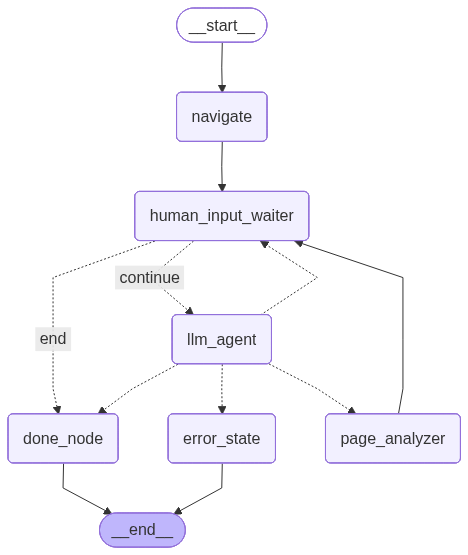

In [118]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [119]:
inputs = {"current_url": "https://www.naver.com"}
for s in graph.stream(inputs):
    print("---")
    print(s)


--- 페이지 탐색 노드 실행 ---
브라우저를 열고 https://www.naver.com로 이동합니다.
---
{'navigate': {'driver': <selenium.webdriver.chrome.webdriver.WebDriver (session="04995c98dc5246991928e98b53eaa008")>, 'current_url': 'https://www.naver.com', 'result': 'https://www.naver.com로 이동했습니다.', 'elements_info': [], 'waiting_for_element_selection': False}}

--- 사용자 입력 대기 노드 실행 ---
다음 작업을 입력해주세요.
예: '검색창에 환율 입력해줘', '검색 버튼을 클릭해줘', '그만'
---
{'human_input_waiter': {'human_input': '검색창에 환율을 입력하고 엔터를 눌러줘'}}

--- LLM 에이전트 노드 실행 ---
LLM 응답: {'tool': 'fill_text', 'args': {'selector': '#query', 'text': '환율'}}
도구 실행 결과: 텍스트 '환율'가 '#query'에 성공적으로 입력되었습니다.
---
{'llm_agent': {'result': "텍스트 '환율'가 '#query'에 성공적으로 입력되었습니다.", 'next_step': 'human_input_waiter', 'waiting_for_element_selection': False}}

--- 사용자 입력 대기 노드 실행 ---
다음 작업을 입력해주세요.
예: '검색창에 환율 입력해줘', '검색 버튼을 클릭해줘', '그만'
---
{'human_input_waiter': {'human_input': '엔터를 눌러줘'}}

--- LLM 에이전트 노드 실행 ---
LLM 응답: {'tool': 'press_key', 'args': {'selector': '#query', 'key': 'ENTER'}}